# Satellite Orbit Tracking with Kalman Filters

A realistic example: tracking a satellite in Low Earth Orbit (LEO) using noisy radar measurements from a ground station.

**Physics:**
- Satellite follows Keplerian two-body dynamics (nonlinear ODE)
- State: $[x, y, v_x, v_y]$ in the orbital plane (2D simplification)
- Ground station at a fixed position measures **range** and **bearing** (nonlinear observation model)

**Filters compared:**
- **KalmanFilter** — linear constant-velocity model (baseline)
- **ExtendedKalmanFilter** — full orbital dynamics with analytical Jacobian
- **UnscentedKalmanFilter** — full orbital dynamics, no Jacobian needed
- **VBKalmanFilter** — linear model with adaptive measurement noise

This demonstrates how the library handles a real-world nonlinear estimation problem with physically meaningful dynamics.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from kalman.filters import KalmanFilter
from kalman.extended import ExtendedKalmanFilter
from kalman.unscented import UnscentedKalmanFilter
from kalman.vkf import VBKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100


## 1. Orbital Mechanics Simulation

We simulate a satellite in a slightly elliptical LEO orbit using Newtonian gravity:

$$\ddot{\mathbf{r}} = -\frac{\mu}{|\mathbf{r}|^3} \mathbf{r}$$

where $\mu = GM_{\oplus} \approx 3.986 \times 10^{14}$ m$^3$/s$^2$.

For numerical convenience, we normalize: distances in units of $R_\oplus = 6371$ km, time in units such that the orbital period is $2\pi$.


Initial state: pos=(1.063, 0.000), vel=(0.000, 0.989)
Circular velocity: 0.9699
Orbital period: ~6.89 time units


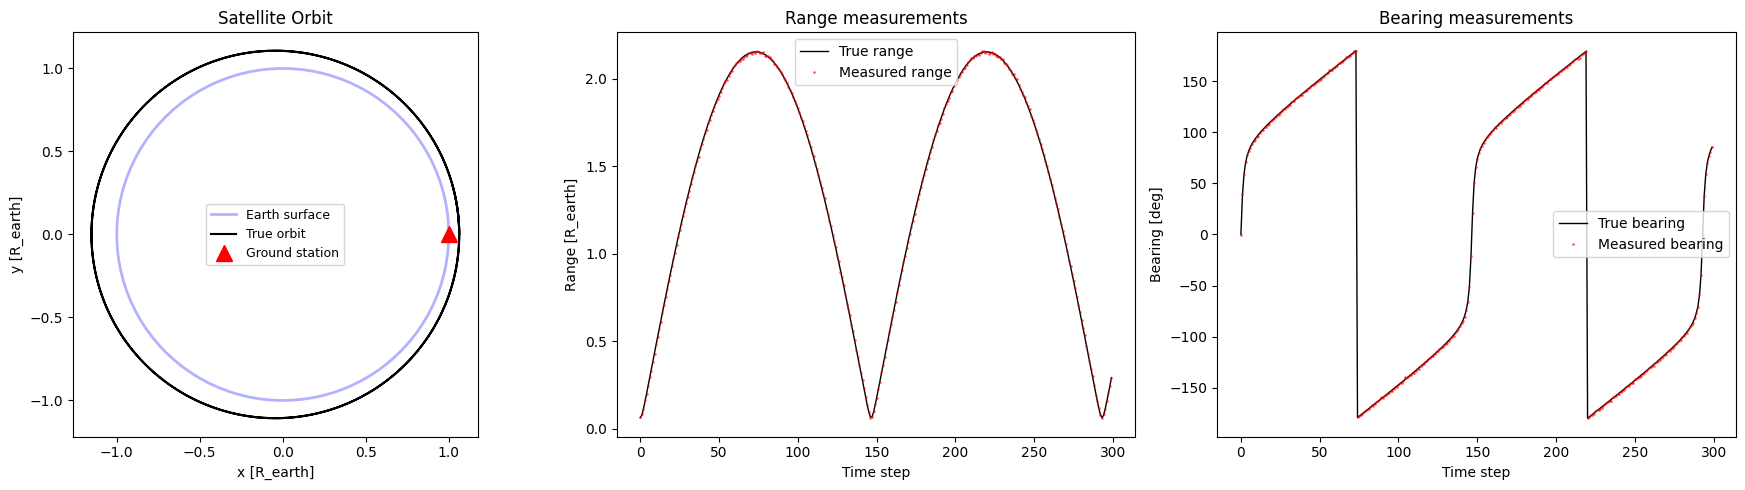

In [2]:
# Normalized units: distance in R_earth, time scaled so mu = 1
# This gives orbital period ~ 2*pi for circular LEO
mu = 1.0  # gravitational parameter (normalized)

# Satellite initial conditions: slightly elliptical orbit
# altitude ~400 km => r ~ 1.063 R_earth
r0 = 1.063  # initial radius (normalized)
v_circular = np.sqrt(mu / r0)  # circular orbit velocity
eccentricity = 0.02  # slight ellipticity

x0 = np.array([r0, 0.0, 0.0, v_circular * (1 + eccentricity)])
print(f"Initial state: pos=({x0[0]:.3f}, {x0[1]:.3f}), vel=({x0[2]:.3f}, {x0[3]:.3f})")
print(f"Circular velocity: {v_circular:.4f}")
print(f"Orbital period: ~{2*np.pi*r0/v_circular:.2f} time units")

# Ground station position (on Earth's surface)
station = np.array([1.0, 0.0])  # at equator, 0 longitude

# RK4 integrator for orbital dynamics
def orbital_rhs(state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -mu * x / r**3
    ay = -mu * y / r**3
    return np.array([vx, vy, ax, ay])

def rk4_step(state, dt):
    k1 = orbital_rhs(state)
    k2 = orbital_rhs(state + 0.5 * dt * k1)
    k3 = orbital_rhs(state + 0.5 * dt * k2)
    k4 = orbital_rhs(state + dt * k3)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# Simulate orbit
dt = 0.05  # time step
T = 300    # number of steps (~2.4 orbits)

true_states = np.zeros((T, 4))
true_states[0] = x0

for t in range(1, T):
    true_states[t] = rk4_step(true_states[t-1], dt)

# Generate noisy radar measurements: range and bearing from ground station
range_noise_std = 0.005   # ~32 km range noise
bearing_noise_std = 0.01  # ~0.6 deg bearing noise

def observe(state, station):
    dx = state[0] - station[0]
    dy = state[1] - station[1]
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    return np.array([r, theta])

observations = np.zeros((T, 2))
for t in range(T):
    observations[t] = observe(true_states[t], station) + \
        np.array([range_noise_std, bearing_noise_std]) * np.random.randn(2)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Orbit
ax = axes[0]
theta_earth = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta_earth), np.sin(theta_earth), 'b-', lw=2, alpha=0.3, label='Earth surface')
ax.plot(true_states[:, 0], true_states[:, 1], 'k-', lw=1.5, label='True orbit')
ax.plot(*station, 'r^', ms=12, label='Ground station')
ax.set_xlabel('x [R_earth]'); ax.set_ylabel('y [R_earth]')
ax.set_title('Satellite Orbit'); ax.legend(fontsize=9); ax.set_aspect('equal')

# Range measurements
ax = axes[1]
true_ranges = np.array([observe(s, station)[0] for s in true_states])
ax.plot(true_ranges, 'k-', lw=1, label='True range')
ax.plot(observations[:, 0], 'r.', ms=2, alpha=0.5, label='Measured range')
ax.set_xlabel('Time step'); ax.set_ylabel('Range [R_earth]')
ax.set_title('Range measurements'); ax.legend()

# Bearing measurements
ax = axes[2]
true_bearings = np.array([observe(s, station)[1] for s in true_states])
ax.plot(np.degrees(true_bearings), 'k-', lw=1, label='True bearing')
ax.plot(np.degrees(observations[:, 1]), 'r.', ms=2, alpha=0.5, label='Measured bearing')
ax.set_xlabel('Time step'); ax.set_ylabel('Bearing [deg]')
ax.set_title('Bearing measurements'); ax.legend()

plt.tight_layout(); plt.show()


## 2. Filter Setup

### Transition models:
- **Linear (KF, VBF):** constant-velocity $x_{t+1} = F x_t$ — poor approximation of orbital motion
- **Nonlinear (EKF, UKF):** RK4-integrated two-body dynamics — physically accurate

### Observation model:
- Range and bearing from ground station: $h(x) = [\sqrt{(x-x_s)^2 + (y-y_s)^2},\; \arctan((y-y_s)/(x-x_s))]$


In [3]:
# ==================== Nonlinear models (EKF, UKF) ====================

# Transition: RK4 step of orbital dynamics in PyTorch
def f_orbital(state):
    """RK4 step of two-body problem."""
    def rhs(s):
        x, y = s[..., 0], s[..., 1]
        vx, vy = s[..., 2], s[..., 3]
        r = torch.sqrt(x**2 + y**2)
        ax = -mu * x / r**3
        ay = -mu * y / r**3
        return torch.stack([vx, vy, ax, ay], dim=-1)
    
    k1 = rhs(state)
    k2 = rhs(state + 0.5 * dt * k1)
    k3 = rhs(state + 0.5 * dt * k2)
    k4 = rhs(state + dt * k3)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# Observation: range and bearing from ground station
station_t = torch.tensor(station, dtype=torch.float64)

def h_radar(state):
    dx = state[..., 0] - station_t[0]
    dy = state[..., 1] - station_t[1]
    r = torch.sqrt(dx**2 + dy**2)
    theta = torch.atan2(dy, dx)
    return torch.stack([r, theta], dim=-1)

# Jacobians for EKF
def F_orbital_jac(state):
    """Numerical Jacobian of the orbital transition via finite differences."""
    n = state.shape[-1]
    eps = 1e-6
    J = torch.zeros(*state.shape[:-1], n, n, dtype=state.dtype)
    f0 = f_orbital(state)
    for i in range(n):
        e = torch.zeros_like(state)
        e[..., i] = eps
        J[..., :, i] = (f_orbital(state + e) - f0) / eps
    return J

def H_radar_jac(state):
    dx = state[..., 0] - station_t[0]
    dy = state[..., 1] - station_t[1]
    r2 = dx**2 + dy**2
    r = torch.sqrt(r2)
    J = torch.zeros(*state.shape[:-1], 2, 4, dtype=state.dtype)
    J[..., 0, 0] = dx / r
    J[..., 0, 1] = dy / r
    J[..., 1, 0] = -dy / r2
    J[..., 1, 1] = dx / r2
    return J

# ==================== Linear model (KF, VBF) ====================
F_linear = torch.tensor([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
], dtype=torch.float64)

H_linear = torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
], dtype=torch.float64)

# Noise covariances
Q = torch.eye(4, dtype=torch.float64) * 1e-6  # small process noise (orbital dynamics are precise)
R = torch.diag(torch.tensor([range_noise_std**2, bearing_noise_std**2], dtype=torch.float64))
R_linear = torch.eye(2, dtype=torch.float64) * 0.01  # for linear model (Cartesian)

print("Models ready")


Models ready


## 3. Running All Filters

In [4]:
# Initial state estimate (rough: we know it's in orbit but not exact position)
init_mean = torch.tensor([1.05, 0.05, 0.0, 0.95], dtype=torch.float64)
init_cov = torch.diag(torch.tensor([0.01, 0.01, 0.01, 0.01], dtype=torch.float64))

obs_t = torch.tensor(observations, dtype=torch.float64)
# Cartesian observations for linear filters
obs_cart = torch.tensor(true_states[:, :2] + np.random.randn(T, 2) * 0.01, dtype=torch.float64)

results = {}

# ---- EKF ----
ekf = ExtendedKalmanFilter(4, 2, f_orbital, h_radar,
    F_jacobian=F_orbital_jac, H_jacobian=H_radar_jac, Q=Q, R=R, eps=1e-10)

state = GaussianState(init_mean.clone(), init_cov.clone())
means = []
for t in range(T):
    state = ekf.predict(state)
    state = ekf.update(state, obs_t[t])
    means.append(state.mean.detach().numpy())
results['EKF'] = np.array(means)
print(f"EKF done")

# ---- UKF ----
ukf = UnscentedKalmanFilter(4, 2, f_orbital, h_radar,
    alpha=1e-3, beta=2.0, kappa=0.0, Q=Q, R=R)

state = GaussianState(init_mean.clone(), init_cov.clone())
means = []
for t in range(T):
    state = ukf.predict(state)
    state = ukf.update(state, obs_t[t])
    means.append(state.mean.detach().numpy())
results['UKF'] = np.array(means)
print(f"UKF done")

# ---- KF (linear, Cartesian obs) ----
kf = KalmanFilter(F_linear, H_linear, Q, R_linear)
state = GaussianState(init_mean.clone(), init_cov.clone())
means = []
for t in range(T):
    state = kf.predict(state)
    state = kf.update(state, obs_cart[t])
    means.append(state.mean.detach().numpy())
results['KF'] = np.array(means)
print(f"KF done")

# ---- VBF (linear, Cartesian obs, wrong initial R) ----
vbf = VBKalmanFilter(F_linear, H_linear, Q,
    initial_measurement_cov=torch.eye(2, dtype=torch.float64) * 0.1,  # 10x overestimate
    rho=0.95)
state = GaussianState(init_mean.clone(), init_cov.clone())
means = []
vbf_R_est = []
for t in range(T):
    state = vbf.predict(state)
    state = vbf.update(state, obs_cart[t])
    means.append(state.mean.detach().numpy())
    vbf_R_est.append(vbf.get_measurement_covariance().detach().numpy()[0,0])
results['VBF'] = np.array(means)
print(f"VBF done")


EKF done
UKF done
KF done
VBF done


## 4. Results

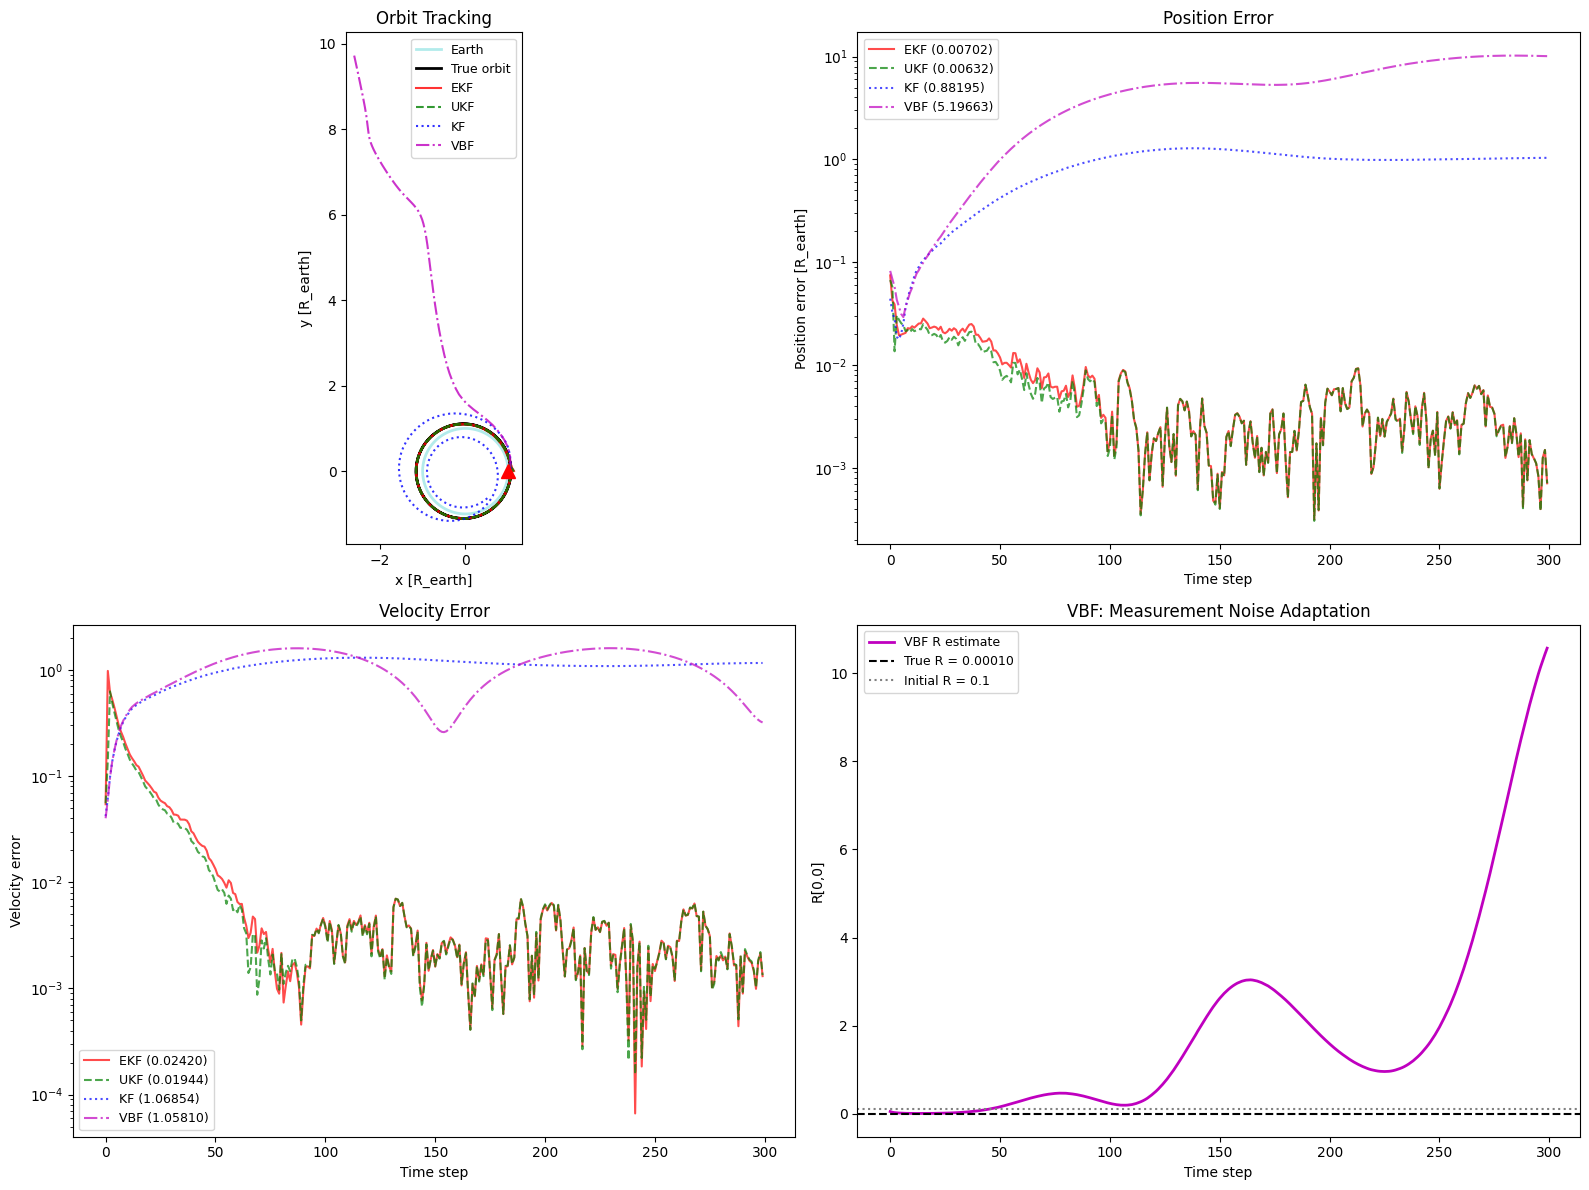

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Orbit tracking ----
ax = axes[0, 0]
ax.plot(np.cos(theta_earth), np.sin(theta_earth), 'c-', lw=2, alpha=0.3, label='Earth')
ax.plot(true_states[:, 0], true_states[:, 1], 'k-', lw=2, label='True orbit')
colors = {'EKF': 'r', 'UKF': 'g', 'KF': 'b', 'VBF': 'm'}
styles = {'EKF': '-', 'UKF': '--', 'KF': ':', 'VBF': '-.'}
for name, m in results.items():
    ax.plot(m[:, 0], m[:, 1], color=colors[name], linestyle=styles[name], 
            alpha=0.8, label=name)
ax.plot(*station, 'r^', ms=10)
ax.set_xlabel('x [R_earth]'); ax.set_ylabel('y [R_earth]')
ax.set_title('Orbit Tracking'); ax.legend(fontsize=9); ax.set_aspect('equal')

# ---- Position RMSE ----
ax = axes[0, 1]
for name, m in results.items():
    err = np.sqrt(np.sum((m[:, :2] - true_states[:, :2])**2, axis=1))
    ax.plot(err, color=colors[name], linestyle=styles[name], 
            alpha=0.7, label=f'{name} ({err.mean():.5f})')
ax.set_xlabel('Time step'); ax.set_ylabel('Position error [R_earth]')
ax.set_title('Position Error'); ax.legend(fontsize=9)
ax.set_yscale('log')

# ---- Velocity RMSE ----
ax = axes[1, 0]
for name, m in results.items():
    err = np.sqrt(np.sum((m[:, 2:] - true_states[:, 2:])**2, axis=1))
    ax.plot(err, color=colors[name], linestyle=styles[name], 
            alpha=0.7, label=f'{name} ({err.mean():.5f})')
ax.set_xlabel('Time step'); ax.set_ylabel('Velocity error')
ax.set_title('Velocity Error'); ax.legend(fontsize=9)
ax.set_yscale('log')

# ---- VBF R adaptation ----
ax = axes[1, 1]
ax.plot(vbf_R_est, 'm-', lw=2, label='VBF R estimate')
ax.axhline(y=0.01**2, color='k', linestyle='--', label=f'True R = {0.01**2:.5f}')
ax.axhline(y=0.1, color='gray', linestyle=':', label=f'Initial R = 0.1')
ax.set_xlabel('Time step'); ax.set_ylabel('R[0,0]')
ax.set_title('VBF: Measurement Noise Adaptation'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()


In [6]:
# Summary table
print("=" * 60)
print(f"{'Filter':<8} {'Mean pos err':<18} {'Mean vel err':<18}")
print("=" * 60)
for name, m in results.items():
    pos_err = np.sqrt(np.sum((m[:, :2] - true_states[:, :2])**2, axis=1)).mean()
    vel_err = np.sqrt(np.sum((m[:, 2:] - true_states[:, 2:])**2, axis=1)).mean()
    print(f"{name:<8} {pos_err:<18.6f} {vel_err:<18.6f}")
print("=" * 60)
print()
print("EKF and UKF use the true orbital dynamics model => much better accuracy.")
print("KF and VBF use a simple constant-velocity model => drift on curved orbit.")
print(f"VBF adapted R from 0.1 to {vbf_R_est[-1]:.6f} (true: {0.01**2:.6f})")


Filter   Mean pos err       Mean vel err      
EKF      0.007018           0.024199          
UKF      0.006316           0.019443          
KF       0.881950           1.068536          
VBF      5.196631           1.058099          

EKF and UKF use the true orbital dynamics model => much better accuracy.
KF and VBF use a simple constant-velocity model => drift on curved orbit.
VBF adapted R from 0.1 to 10.568362 (true: 0.000100)


## 5. Training: Learning Orbital Parameters

We can also use the library's PyTorch integration to **learn** unknown physical parameters.
Example: learning the gravitational parameter $\mu$ from observations.


/home/kreinin.mv/university/Kalman-filter-and-his-friends/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


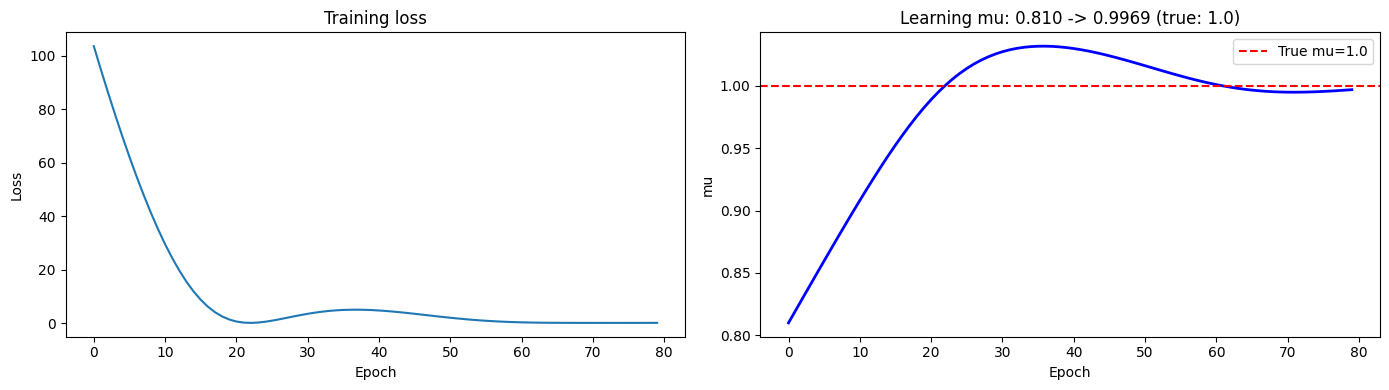

In [7]:
# Parameterize mu as a learnable scalar
mu_param = torch.tensor(0.8, dtype=torch.float64, requires_grad=True)  # wrong initial guess

def f_orbital_learnable(state):
    def rhs(s):
        x, y = s[..., 0], s[..., 1]
        vx, vy = s[..., 2], s[..., 3]
        r = torch.sqrt(x**2 + y**2)
        ax = -mu_param * x / r**3
        ay = -mu_param * y / r**3
        return torch.stack([vx, vy, ax, ay], dim=-1)
    k1 = rhs(state)
    k2 = rhs(state + 0.5 * dt * k1)
    k3 = rhs(state + 0.5 * dt * k2)
    k4 = rhs(state + dt * k3)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

optimizer = torch.optim.Adam([mu_param], lr=0.01)

losses = []
mu_values = []

for epoch in range(80):
    optimizer.zero_grad()
    
    state = GaussianState(
        torch.tensor(x0, dtype=torch.float64),
        torch.eye(4, dtype=torch.float64) * 0.001,
    )
    
    loss = torch.tensor(0.0, dtype=torch.float64)
    for t in range(min(T, 100)):  # use first 100 steps
        pred_state = f_orbital_learnable(state.mean)
        true_pos = torch.tensor(true_states[t, :2], dtype=torch.float64)
        loss = loss + ((pred_state[:2] - true_pos)**2).sum()
        state = GaussianState(pred_state.detach(), state.covariance)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    mu_values.append(mu_param.item())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss')
axes[1].plot(mu_values, 'b-', lw=2); axes[1].axhline(y=1.0, color='r', linestyle='--', label='True mu=1.0')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mu'); axes[1].legend()
axes[1].set_title(f'Learning mu: {mu_values[0]:.3f} -> {mu_values[-1]:.4f} (true: 1.0)')
plt.tight_layout(); plt.show()


## Summary

This example demonstrates the library on a physically realistic satellite tracking problem:

1. **Nonlinear dynamics** — Keplerian two-body orbital mechanics (integrated with RK4)
2. **Nonlinear observations** — range and bearing from a ground-based radar
3. **EKF and UKF** achieve high accuracy by using the true orbital model
4. **KF and VBF** serve as baselines with a simplified linear model
5. **VBF** adapts its measurement noise estimate from a wrong initial value
6. **Trainable parameters** — the gravitational constant $\mu$ can be learned from data via PyTorch autograd
